In [1]:
!pip install --no-index seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
mac = [5, 10, 20, 50]

# Eigenvalue-based
eigen_meff = {
    'ALL': [71, 70, 69, 69],
    'AFR': [66, 65, 66, 65],
    'AMR': [59, 61, 63, 70],
    'EAS': [59, 58, 60, 63],
    'EUR': [61, 61, 61, 61],
    'SAS': [60, 71, 62, 62]
}

# Simulated continuous phenotypes
sim_cont_meff = {
    'ALL': [92, 91, 93, 91],
    'AFR': [91, 90, 90, 88],
    'AMR': [93, 96, 90, 95],
    'EAS': [92, 91, 89, 89],
    'EUR': [88, 89, 86, 85],
    'SAS': [92, 96, 91, 93],
}

# Simulated binary phenotypes: 10% cases
sim_bin10_meff = {
    'ALL': [79, 79, 81, 87],
    'AFR': [73, 74, 75, 85],
    'AMR': [62, 64, 65, 84],
    'EAS': [69, 67, 70, 76],
    'EUR': [68, 68, 70, 76],
    'SAS': [63, 67, 67, 72],
}

# Simulated binary phenotypes: 20% cases
sim_bin20_meff = {
    'ALL': [75, 80, 85, 92],
    'AFR': [73, 75, 79, 87],
    'AMR': [63, 69, 75, 87],
    'EAS': [68, 70, 75, 82],
    'EUR': [67, 70, 75, 82],
    'SAS': [68, 75, 79, 86]
}

# Simulated binary phenotypes: 30% cases
sim_bin30_meff = {
    'ALL': [74, 83, 87, 93],
    'AFR': [77, 83, 89, 90],
    'AMR': [63, 72, 86, 89],
    'EAS': [69, 75, 80, 86],
    'EUR': [68, 75, 80, 80],
    'SAS': [68, 76, 85, 87]
}


/tmp/ipykernel_956485/2309064528.py:81: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_956485/2309064528.py:81: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_956485/2309064528.py:81: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_956485/2309064528.py:81: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.lineplot(
/tmp/ipykernel_956485/2309064528.py:81: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.lineplot(


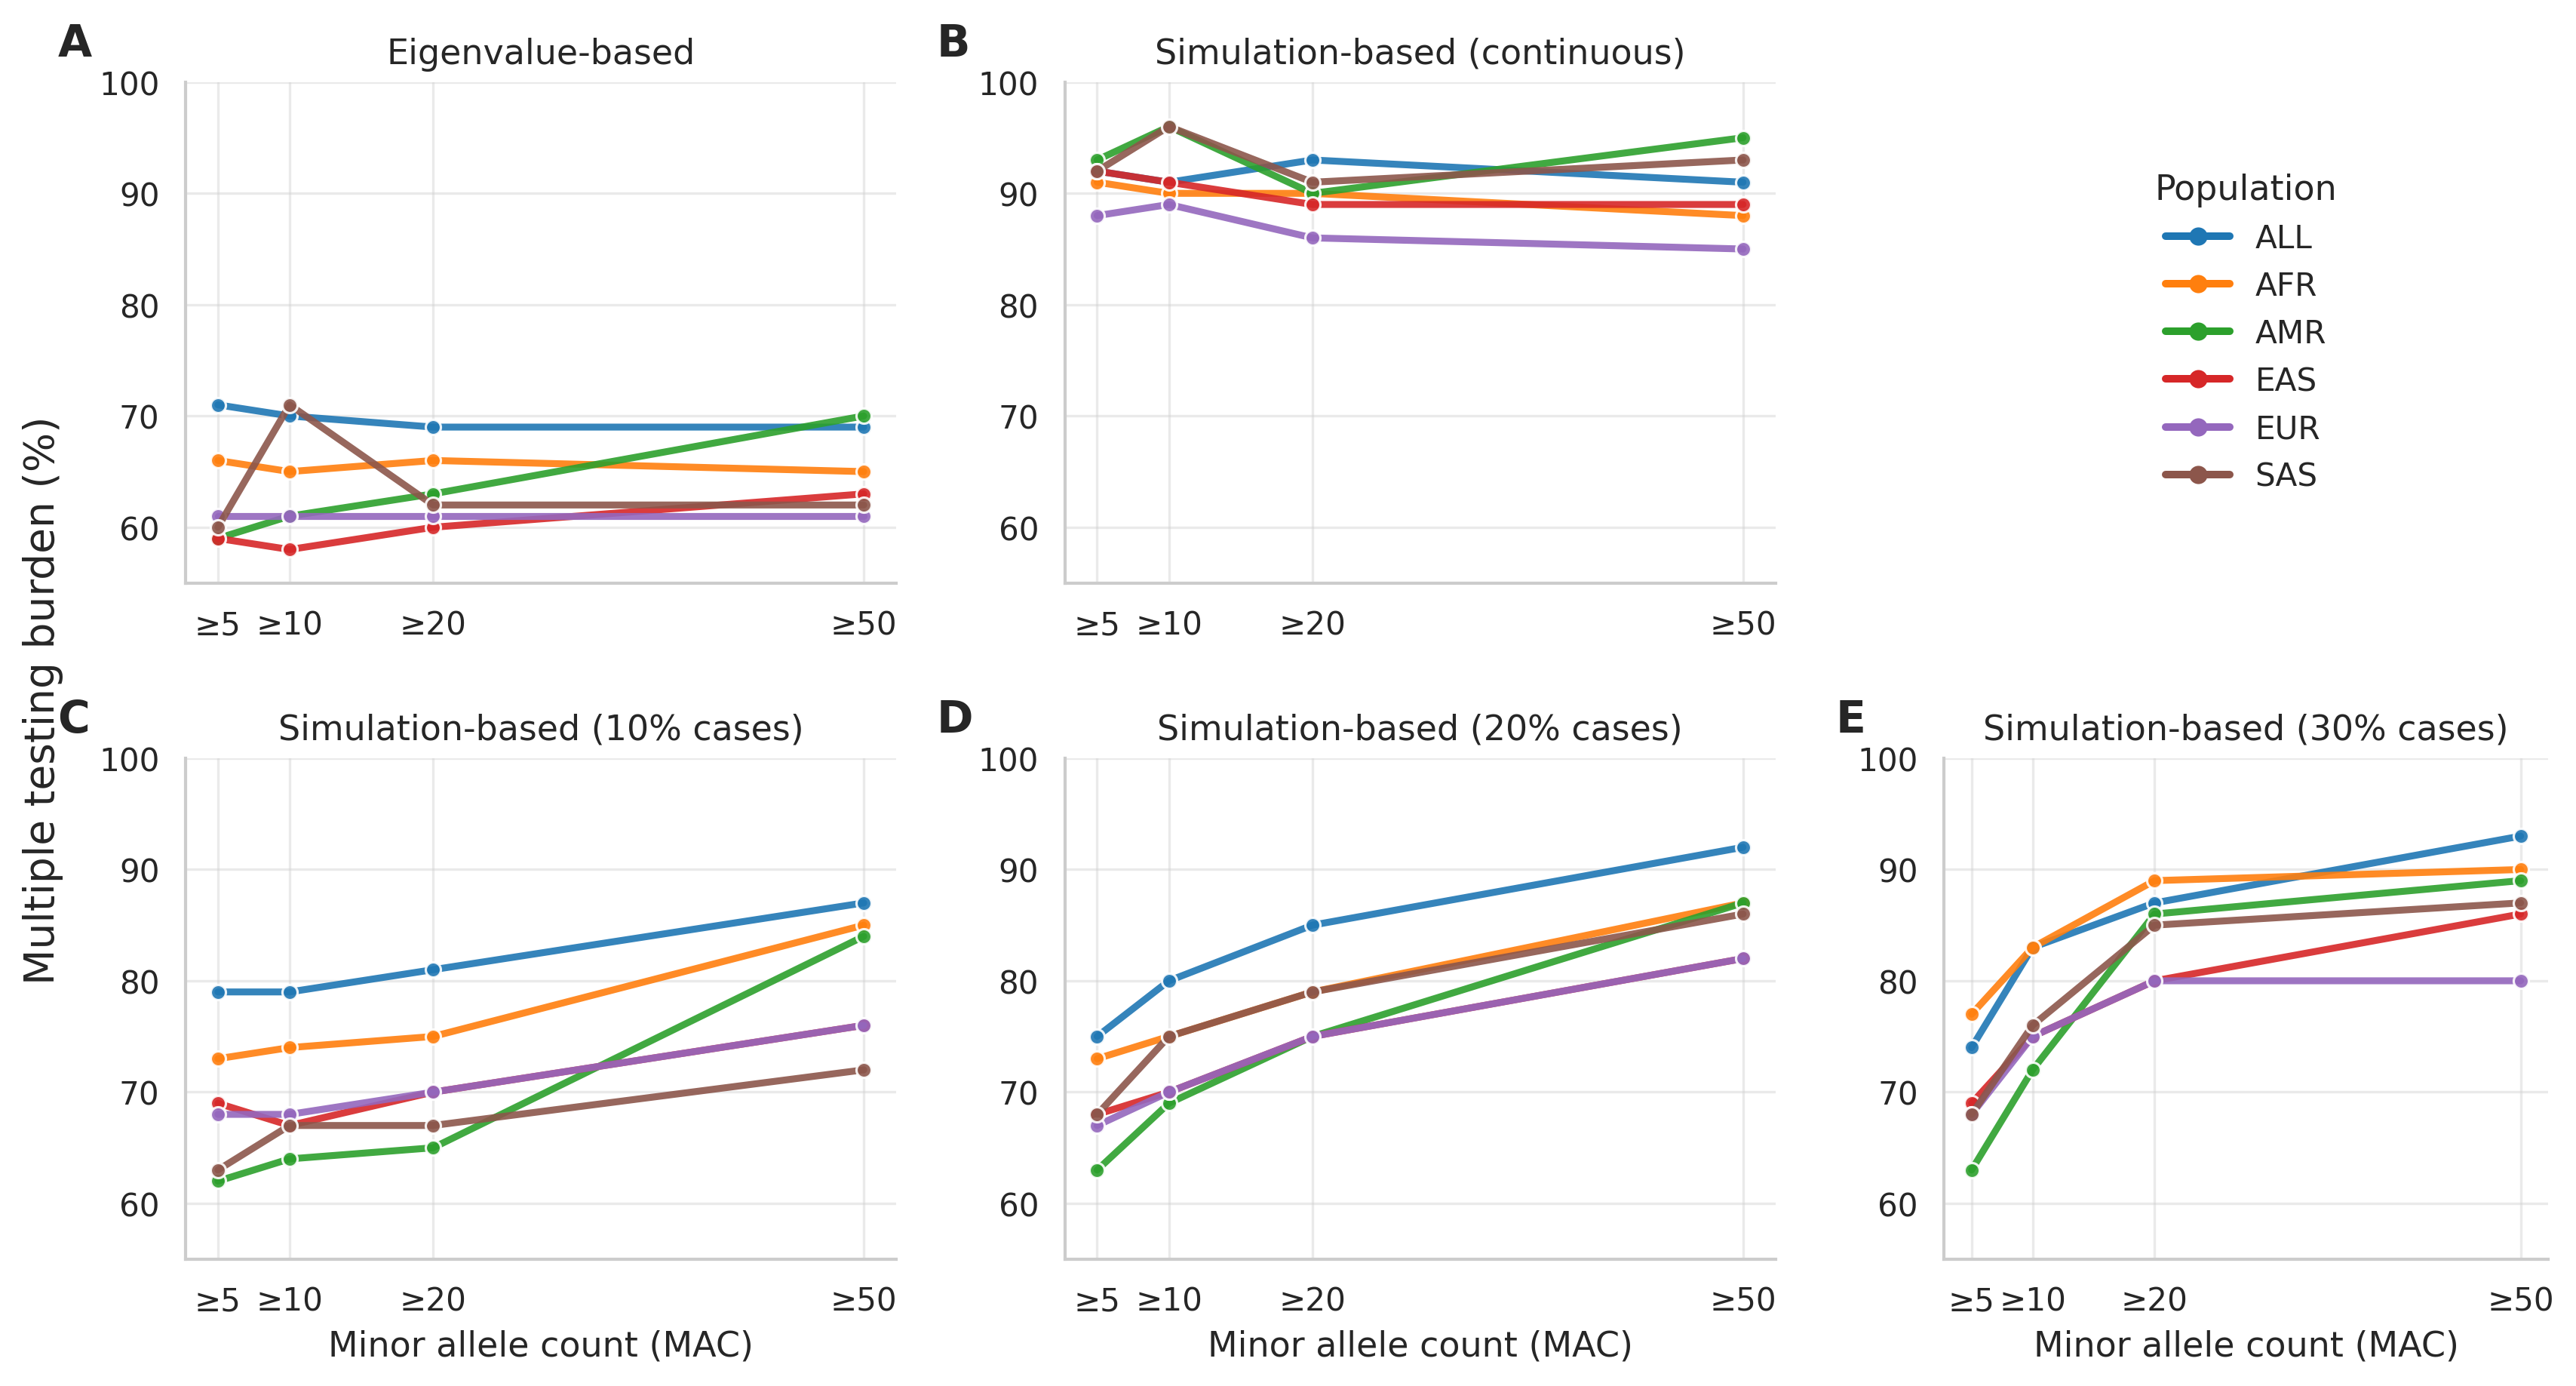

In [3]:
# ----------------------------
# long format
# ----------------------------
def to_long(df_dict, method_name):
    rows = []
    for pop, values in df_dict.items():
        for m, v in zip(mac, values):
            rows.append({
                "MAC": m,
                "Burden": v,
                "Population": pop,
                "Method": method_name
            })
    return pd.DataFrame(rows)

df = pd.concat([
    to_long(eigen_meff, "Eigenvalue-based"),
    to_long(sim_cont_meff, "Simulation-based (continuous)"),
    to_long(sim_bin10_meff, "Simulation-based (10% cases)"),
    to_long(sim_bin20_meff, "Simulation-based (20% cases)"),
    to_long(sim_bin30_meff, "Simulation-based (30% cases)")
], ignore_index=True)

# ----------------------------
# ordering
# ----------------------------
methods = [
    "Eigenvalue-based",
    "Simulation-based (continuous)",
    "Simulation-based (10% cases)",
    "Simulation-based (20% cases)",
    "Simulation-based (30% cases)"
]

mac_order = [5, 10, 20, 50]

df["Method"] = pd.Categorical(df["Method"], categories=methods, ordered=True)
df["MAC"] = pd.Categorical(df["MAC"], categories=mac_order, ordered=True)

# ----------------------------
# style
# ----------------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

palette = sns.color_palette("tab10")

# ----------------------------
# layout
# ----------------------------
fig = plt.figure(figsize=(12, 6.5))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 0.85],
    wspace=0.25,
    hspace=0.35
)

axes = {
    "Eigenvalue-based": fig.add_subplot(gs[0, 0]),
    "Simulation-based (continuous)": fig.add_subplot(gs[0, 1]),
    "Simulation-based (10% cases)": fig.add_subplot(gs[1, 0]),
    "Simulation-based (20% cases)": fig.add_subplot(gs[1, 1]),
    "Simulation-based (30% cases)": fig.add_subplot(gs[1, 2]),
}

ax_leg = fig.add_subplot(gs[0, 2])

# ----------------------------
# plotting
# ----------------------------
for method, ax in axes.items():
    sub = df[df["Method"] == method]

    sns.lineplot(
        data=sub,
        x="MAC",
        y="Burden",
        hue="Population",
        marker="o",
        linewidth=2.4,
        palette=palette,
        ax=ax,
        legend=False
    )

    ax.set_title(method)

    # x-axis formatting
    ax.set_xticks(mac_order)
    ax.set_xticklabels([r"≥5", r"≥10", r"≥20", r"≥50"])

    ax.set_ylim(55, 100)

    # remove repeated labels
    ax.set_ylabel("")
    if method in ["Simulation-based (10% cases)", "Simulation-based (20% cases)", "Simulation-based (30% cases)"]:
        ax.set_xlabel("Minor allele count (MAC)")
    else:
        ax.set_xlabel("")

    # grid
    ax.grid(True, axis="both", alpha=0.4, linewidth=0.8)

    for line in ax.lines:
        line.set_alpha(0.9)
        line.set_linewidth(2.2)

# ----------------------------
# shared y-label
# ----------------------------
fig.supylabel("Multiple testing burden (%)")

# ----------------------------
# legend
# ----------------------------
ax_leg.axis("off")

populations = list(eigen_meff.keys())
colors = palette[:len(populations)]

legend_handles = [
    Line2D([0], [0], color=colors[i], lw=2.4, marker='o', label=pop)
    for i, pop in enumerate(populations)
]

ax_leg.legend(
    handles=legend_handles,
    title="Population",
    loc="center",
    frameon=False
)

# ----------------------------
# panel labels (FIXED: no overlap)
# ----------------------------
panel_labels = ["A", "B", "C", "D", "E"]

for i, (method, ax) in enumerate(axes.items()):
    ax.text(
        -0.18, 1.12,   # moved outside to avoid tick overlap
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

# ----------------------------
# final layout tuning
# ----------------------------
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    top=0.92,
    bottom=0.12
)

# plt.savefig("meff_nature_genetics_final.pdf", bbox_inches="tight")
# plt.savefig("meff_nature_genetics_final.png", bbox_inches="tight")

plt.show()